<a href="https://colab.research.google.com/github/SultanKus/Bancassurance-Analytics-Project/blob/main/Bancassurance_Analytics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Sonuçların her seferinde aynı çıkması için seed belirliyoruz
np.random.seed(42)
n_customers = 10000

# 1. Kredi Verisi Oluşturma (%98 kredisini ödeyen, %2 batan dengesiz veri)
df_credit = pd.DataFrame({
    'Customer_ID': range(1, n_customers + 1),
    'Age': np.random.randint(22, 65, n_customers),
    'Income': np.random.normal(15000, 5000, n_customers), # Normal dağılım ile gelir
    'Credit_Score': np.random.normal(650, 100, n_customers), # Normal dağılım ile skor
    'Default_Flag': np.random.choice([0, 1], size=n_customers, p=[0.98, 0.02])
})

In [10]:
import pandas as pd
import os

# Senin kopyaladığın yolu kullanıyoruz
dosya_yolu = '/application_train.csv'

# Eğer dosya bu yolda değilse, standart Colab yoluna baksın
if not os.path.exists(dosya_yolu):
    dosya_yolu = '/content/application_train.csv'

# Veriyi okutuyoruz
df = pd.read_csv(dosya_yolu)

print("Veri başarıyla yüklendi! Tablo boyutu:", df.shape)

Veri başarıyla yüklendi! Tablo boyutu: (307511, 122)


In [13]:
# Hedef değişkendeki (TARGET) oranları hesaplıyoruz
target_counts = df['TARGET'].value_counts()
target_rates = df['TARGET'].value_counts(normalize=True) * 100

print("--- Kredi Geri Ödeme Durumu ---")
print(f"0 (Sorunsuz Ödeyenler): {target_counts[0]:,} kişi (%{target_rates[0]:.2f})")
print(f"1 (Batık Krediler): {target_counts[1]:,} kişi (%{target_rates[1]:.2f})")

--- Kredi Geri Ödeme Durumu ---
0 (Sorunsuz Ödeyenler): 282,686 kişi (%91.93)
1 (Batık Krediler): 24,825 kişi (%8.07)


In [14]:
# 1. Kullanacağımız kritik özellikleri (sütunları) seçiyoruz
secilen_sutunlar = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH']
df_kredi = df[secilen_sutunlar].copy() # Ana veriyi bozmamak için kopyasını alıyoruz

# 2. Veri Dönüşümü: Gün cinsinden ve negatif olan yaşı, normal YIL formatına çeviriyoruz
# Abs mutlak değer alır, 365'e böler ve astype(int) ile tam sayıya çevirir
df_kredi['YAS'] = (df_kredi['DAYS_BIRTH'].abs() / 365).astype(int)

# Artık eski DAYS_BIRTH sütununa ihtiyacımız kalmadı, siliyoruz
df_kredi = df_kredi.drop('DAYS_BIRTH', axis=1)

# 3. Eksik (NaN) Verileri Temizleme
# Kredi taksiti (AMT_ANNUITY) sütununda boşluklar olabilir. Bunları medyan (orta değer) ile dolduruyoruz.
df_kredi['AMT_ANNUITY'] = df_kredi['AMT_ANNUITY'].fillna(df_kredi['AMT_ANNUITY'].median())

# Verinin son haline ve ilk 5 satırına bakalım
print("Eğitim İçin Hazırlanan Veri Boyutu:", df_kredi.shape)
display(df_kredi.head())

Eğitim İçin Hazırlanan Veri Boyutu: (307511, 5)


,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,YAS
0,1,202500.0,406597.5,24700.5,25
1,0,270000.0,1293502.5,35698.5,45
2,0,67500.0,135000.0,6750.0,52
3,0,135000.0,312682.5,29686.5,52
4,0,121500.0,513000.0,21865.5,54


In [15]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

# 1. Hedef Değişken (y) ve Tahmin Edicileri (X) ayırıyoruz
X = df_kredi.drop('TARGET', axis=1) # TARGET dışındaki her şey X (Gelir, Yaş, Kredi Tutarı vs.)
y = df_kredi['TARGET']              # Tahmin etmeye çalıştığımız şey y (0 veya 1)

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # %20'si test için ayrıldı
    random_state=42,   # Kodu her çalıştırdığımızda aynı ayrımı yapsın diye sabitliyoruz
    stratify=y         # %8'lik batık oranı iki tarafta da korunsun
)

print(f"Modele ders çalışması için verilen müşteri sayısı: {X_train.shape[0]}")
print(f"Modeli test edeceğimiz müşteri sayısı: {X_test.shape[0]}")

# 3. Modeli Kuruyoruz
lgb_model = lgb.LGBMClassifier(
    is_unbalance=True, # Dengesiz veri uyarısını açtık!
    random_state=42
)

# 4. Modeli Eğitiyoruz (Öğrenme aşaması)
lgb_model.fit(X_train, y_train)

print("\nModel başarıyla eğitildi! Artık sınava hazır.")

Modele ders çalışması için verilen müşteri sayısı: 246008
Modeli test edeceğimiz müşteri sayısı: 61503
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 760
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

Model başarıyla eğitildi! Artık sınava hazır.


--- MODELİN KARNESİ ---
Genel Doğruluk (Accuracy): %63.82

Accuracy yüksek görünebilir ama bu bir tuzak! Detaylı rapor (F1-Score):
              precision    recall  f1-score   support

           0       0.94      0.65      0.77     56538
           1       0.12      0.55      0.20      4965

    accuracy                           0.64     61503
   macro avg       0.53      0.60      0.48     61503
weighted avg       0.88      0.64      0.72     61503



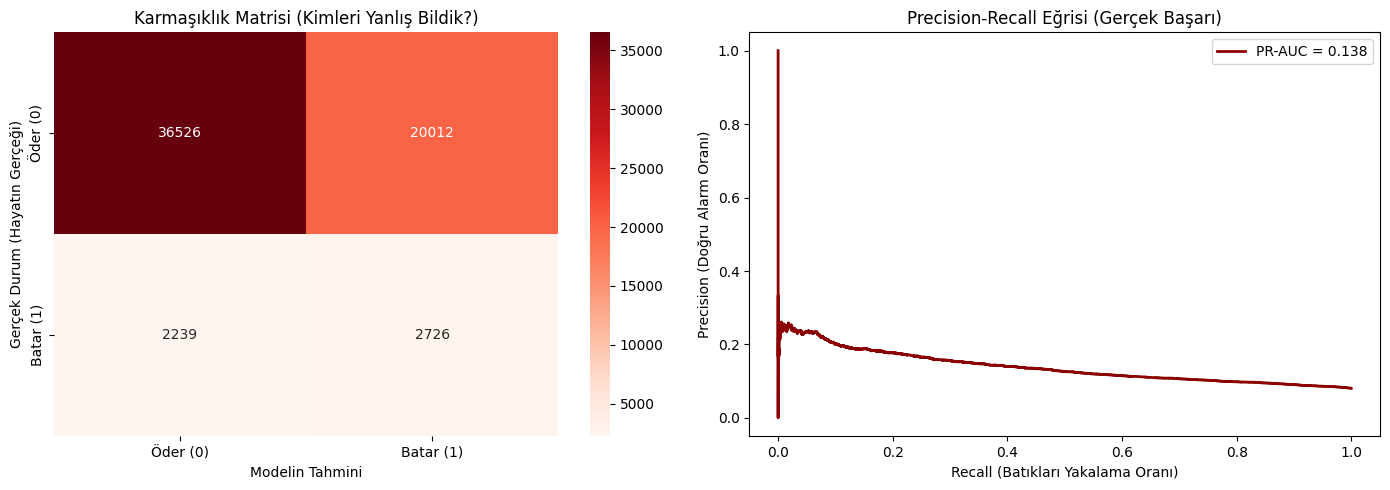

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SINAV AŞAMASI (Tahminler)
# Modelden X_test'teki müşterilerin krediyi batırıp batırmayacağını tahmin etmesini istiyoruz
y_pred = lgb_model.predict(X_test)             # Modelin kesin kararları (0 veya 1)
y_prob = lgb_model.predict_proba(X_test)[:, 1] # Modelin "batar" deme ihtimali (Olasılık %)

# 2. KARNE (Metriklerin Hesaplanması)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print(f"--- MODELİN KARNESİ ---")
print(f"Genel Doğruluk (Accuracy): %{accuracy*100:.2f}")
print("\nAccuracy yüksek görünebilir ama bu bir tuzak! Detaylı rapor (F1-Score):")
print(classification_report(y_test, y_pred))

# 3. GÖRSELLEŞTİRME ŞOV (Confusion Matrix ve PR-AUC)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Sol Grafik: Confusion Matrix (Karmaşıklık Matrisi)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title('Karmaşıklık Matrisi (Kimleri Yanlış Bildik?)')
ax[0].set_xlabel('Modelin Tahmini')
ax[0].set_ylabel('Gerçek Durum (Hayatın Gerçeği)')
ax[0].xaxis.set_ticklabels(['Öder (0)', 'Batar (1)'])
ax[0].yaxis.set_ticklabels(['Öder (0)', 'Batar (1)'])

# Sağ Grafik: PR-AUC Eğrisi
ax[1].plot(recall, precision, color='darkred', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax[1].set_xlabel('Recall (Batıkları Yakalama Oranı)')
ax[1].set_ylabel('Precision (Doğru Alarm Oranı)')
ax[1].set_title('Precision-Recall Eğrisi (Gerçek Başarı)')
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()